In [1]:
pip install --upgrade pip && pip install "numpy==1.26.4" snntorch h5py scikit-learn matplotlib

Note: you may need to restart the kernel to use updated packages.


Loading dataset...
✅ Shapes before processing: (100000, 3000, 1) (100000, 3000) (100000, 3000, 1) (100000, 3000)
Label distribution (train): [296511283   2639999    848718]
Label distribution (test): [296518112   2640372    841516]
Using device: cuda
🔄 Resuming training from checkpoints_snn_seq_3000_batch0_multiclass_v12/last.pt

🔎 Training complete. Best model saved in checkpoints_snn_seq_3000_batch0_multiclass_v12
📈 Saved training curves to results/training_curve_v12.png


/tmp/ipykernel_373/526086724.py:235: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load(os.path.join(CHECKPOINT_DIR, "best.pt"), map_location=dev

✅ Saved results to results/snn_seq_3000_batch0_multiclass_cluster_v12.npz


ValueError: operands could not be broadcast together with shapes (300000000,) (100000,3000) 

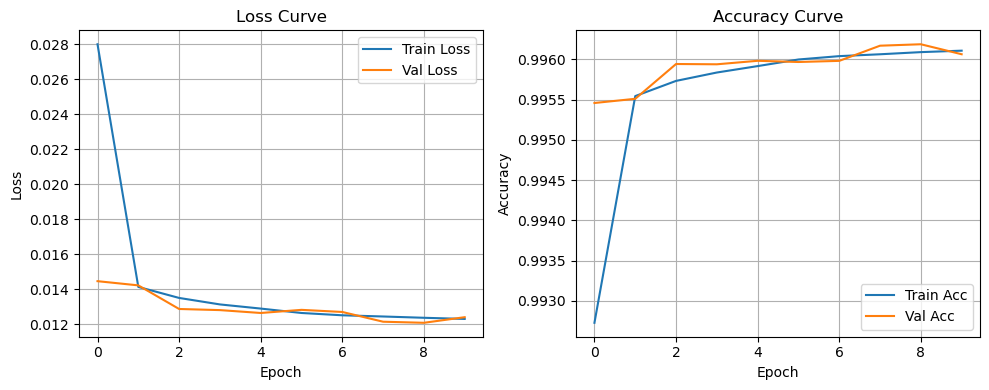

In [1]:
import os
import numpy as np
import torch
import torch.nn as nn
import snntorch as snn
from torch.utils.data import DataLoader, TensorDataset
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
from tqdm import tqdm
from sklearn.metrics import classification_report, confusion_matrix

# ============================================================
# === CONFIG ===
# ============================================================
CACHE_PATH = "cached_data/TimeSeries_seq_3000_batch0.npz"

CHECKPOINT_DIR = "checkpoints_snn_seq_3000_batch0_multiclass_v12"
RESULT_PATH = "results/snn_seq_3000_batch0_multiclass_cluster_v12.npz"
OUT_FIG_BEST = "results/purity_efficiency_best_v12.png"
OUT_FIG_CURVE = "results/training_curve_v12.png"

BATCH_SIZE = 32
NUM_EPOCHS = 10
PATIENCE = 3
NUM_TIMESTEPS = 20
NUM_CLASSES = 3   # ✅ now 3-way classification

os.makedirs(CHECKPOINT_DIR, exist_ok=True)
os.makedirs("results", exist_ok=True)

# ============================================================
# === Load dataset ===
# ============================================================
print("Loading dataset...")
data = np.load(CACHE_PATH)
X_train, y_train = data["X_train"], data["y_train"]
X_test, y_test   = data["X_test"], data["y_test"]

print("✅ Shapes before processing:", X_train.shape, y_train.shape, X_test.shape, y_test.shape)

# Assume labels are integers representing: 0=background, 1=primary, 2=secondary
# Clip or map to valid 0–2 range
y_train = np.clip(y_train, 0, 2).astype(np.int64)
y_test  = np.clip(y_test, 0, 2).astype(np.int64)

print("Label distribution (train):", np.bincount(y_train.reshape(-1)))
print("Label distribution (test):", np.bincount(y_test.reshape(-1)))

# Normalize input
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train.reshape(-1, 1)).reshape(X_train.shape)
X_test  = scaler.transform(X_test.reshape(-1, 1)).reshape(X_test.shape)

# Torch tensors
X_train_tensor = torch.tensor(X_train, dtype=torch.float32)
y_train_tensor = torch.tensor(y_train, dtype=torch.long)
X_test_tensor  = torch.tensor(X_test, dtype=torch.float32)
y_test_tensor  = torch.tensor(y_test, dtype=torch.long)

train_loader = DataLoader(TensorDataset(X_train_tensor, y_train_tensor),
                          batch_size=BATCH_SIZE, shuffle=True)
test_loader  = DataLoader(TensorDataset(X_test_tensor, y_test_tensor),
                          batch_size=BATCH_SIZE, shuffle=False)

# ============================================================
# === Model (Deeper Conv→LIF stack) ===
# ============================================================
class ConvSNN_Deep(nn.Module):
    def __init__(self, input_dim=1, beta=0.5, num_classes=3):
        super().__init__()
        self.conv1 = nn.Conv1d(input_dim, 32, kernel_size=5, padding=2)
        self.lif1  = snn.Leaky(beta=beta)
        self.conv2 = nn.Conv1d(32, 64, kernel_size=5, padding=2)
        self.lif2  = snn.Leaky(beta=beta)
        self.conv3 = nn.Conv1d(64, 128, kernel_size=5, padding=2)
        self.lif3  = snn.Leaky(beta=beta)
        self.conv4 = nn.Conv1d(128, 128, kernel_size=5, padding=2)
        self.lif4  = snn.Leaky(beta=beta)

        self.fc1   = nn.Linear(128, 128)
        self.lif_fc = snn.Leaky(beta=beta)
        self.fc_out = nn.Linear(128, num_classes)

    def forward(self, x, num_steps=NUM_TIMESTEPS):
        B, T, _ = x.shape
        x = x.permute(0, 2, 1)
        mem1, mem2, mem3, mem4, mem_fc = (
            self.lif1.init_leaky(),
            self.lif2.init_leaky(),
            self.lif3.init_leaky(),
            self.lif4.init_leaky(),
            self.lif_fc.init_leaky(),
        )
        spk_out = []
        for _ in range(num_steps):
            cur1 = self.conv1(x); spk1, mem1 = self.lif1(cur1, mem1)
            cur2 = self.conv2(spk1); spk2, mem2 = self.lif2(cur2, mem2)
            cur3 = self.conv3(spk2); spk3, mem3 = self.lif3(cur3, mem3)
            cur4 = self.conv4(spk3); spk4, mem4 = self.lif4(cur4, mem4)

            spk4 = spk4.permute(0, 2, 1)
            fc = self.fc1(spk4)
            spk_fc, mem_fc = self.lif_fc(fc, mem_fc)
            out = self.fc_out(spk_fc)
            spk_out.append(out)

        return torch.stack(spk_out, dim=2).mean(dim=2)


# ============================================================
# === Training setup + Resume from checkpoint ===
# ============================================================
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

model = ConvSNN_Deep(num_classes=NUM_CLASSES).to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=5e-3)
criterion = nn.CrossEntropyLoss()

best_loss, early_counter = float("inf"), 0
train_curve, val_curve = [], []
train_acc_curve, val_acc_curve = [], []

start_epoch = 1
last_ckpt = os.path.join(CHECKPOINT_DIR, "last.pt")
if os.path.exists(last_ckpt):
    print(f"🔄 Resuming training from {last_ckpt}")
    checkpoint = torch.load(last_ckpt, map_location=device, weights_only=True)
    model.load_state_dict(checkpoint["model_state"])
    optimizer.load_state_dict(checkpoint["optimizer_state"])
    best_loss = checkpoint["best_loss"]
    early_counter = checkpoint["early_counter"]
    start_epoch = checkpoint["epoch"]
    train_curve = checkpoint.get("train_curve", [])
    val_curve = checkpoint.get("val_curve", [])
    train_acc_curve = checkpoint.get("train_acc_curve", [])
    val_acc_curve = checkpoint.get("val_acc_curve", [])

# ============================================================
# === Training loop ===
# ============================================================
for epoch in range(start_epoch, NUM_EPOCHS + 1):
    print(f"\n=== Epoch {epoch}/{NUM_EPOCHS} ===")
    model.train()
    total_loss, correct, total = 0, 0, 0

    for xb, yb in tqdm(train_loader, desc=f"Epoch {epoch} Training", mininterval=1.0):
        xb, yb = xb.to(device), yb.to(device)
        out = model(xb)
        loss = criterion(out.reshape(-1, NUM_CLASSES), yb.reshape(-1))
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        total_loss += loss.item() * xb.size(0)
        preds = out.argmax(dim=-1)
        correct += (preds == yb).sum().item()
        total += yb.numel()

    train_loss = total_loss / len(train_loader.dataset)
    train_acc = correct / total

    # Validation
    val_loss, correct, total = 0, 0, 0
    model.eval()
    with torch.no_grad():
        for xb, yb in test_loader:
            xb, yb = xb.to(device), yb.to(device)
            out = model(xb)
            loss = criterion(out.reshape(-1, NUM_CLASSES), yb.reshape(-1))
            val_loss += loss.item() * xb.size(0)
            preds = out.argmax(dim=-1)
            correct += (preds == yb).sum().item()
            total += yb.numel()

    val_loss /= len(test_loader.dataset)
    val_acc = correct / total
    print(f"Train Loss {train_loss:.4f} | Train Acc {train_acc:.4f} | "
          f"Val Loss {val_loss:.4f} | Val Acc {val_acc:.4f}")

    train_curve.append(train_loss)
    val_curve.append(val_loss)
    train_acc_curve.append(train_acc)
    val_acc_curve.append(val_acc)

    if val_loss < best_loss:
        best_loss = val_loss
        early_counter = 0
        torch.save(model.state_dict(), os.path.join(CHECKPOINT_DIR, "best.pt"))
        print("✅ New best model saved")
    else:
        early_counter += 1
        print(f"⚠️ No improvement ({early_counter}/{PATIENCE})")
        if early_counter >= PATIENCE:
            print("🛑 Early stopping triggered.")
            break

    torch.save({
        "epoch": epoch + 1,
        "model_state": model.state_dict(),
        "optimizer_state": optimizer.state_dict(),
        "best_loss": best_loss,
        "early_counter": early_counter,
        "train_curve": train_curve,
        "val_curve": val_curve,
        "train_acc_curve": train_acc_curve,
        "val_acc_curve": val_acc_curve,
    }, last_ckpt)

print("\n🔎 Training complete. Best model saved in", CHECKPOINT_DIR)

# ============================================================
# === Training curve plot ===
# ============================================================
plt.figure(figsize=(10,4))
plt.subplot(1,2,1)
plt.plot(train_curve, label="Train Loss")
plt.plot(val_curve, label="Val Loss")
plt.xlabel("Epoch"); plt.ylabel("Loss")
plt.title("Loss Curve"); plt.grid(True); plt.legend()

plt.subplot(1,2,2)
plt.plot(train_acc_curve, label="Train Acc")
plt.plot(val_acc_curve, label="Val Acc")
plt.xlabel("Epoch"); plt.ylabel("Accuracy")
plt.title("Accuracy Curve"); plt.grid(True); plt.legend()

plt.tight_layout()
plt.savefig(OUT_FIG_CURVE)
print(f"📈 Saved training curves to {OUT_FIG_CURVE}")

# ============================================================
# === Evaluation ===
# ============================================================
model.load_state_dict(torch.load(os.path.join(CHECKPOINT_DIR, "best.pt"), map_location=device))
model.eval()
y_true_all, y_pred_all = [], []

with torch.no_grad():
    for xb, yb in tqdm(test_loader, desc="Evaluating"):
        xb = xb.to(device)
        out = model(xb)
        probs = torch.softmax(out, dim=-1).cpu().numpy()
        labels = yb.cpu().numpy()
        y_true_all.append(labels)
        y_pred_all.append(probs)

y_true_all = np.concatenate(y_true_all, axis=0)
y_pred_all = np.concatenate(y_pred_all, axis=0)

np.savez(RESULT_PATH, probs=y_pred_all, y_true=y_true_all)
print(f"✅ Saved results to {RESULT_PATH}")

# ============================================================
# === Purity/Efficiency per class ===
# ============================================================
def purity_efficiency_multiclass(y_true, y_probs, nclasses=3, thresholds=None):
    if thresholds is None:
        thresholds = np.linspace(0, 1, 101)
    results = []
    for cls in range(nclasses):
        yt = (y_true == cls)
        pp = y_probs[:, :, cls].reshape(-1)
        purity, efficiency = [], []
        for thr in thresholds:
            pred = pp >= thr
            TP = np.sum(pred & yt)
            FP = np.sum(pred & ~yt)
            FN = np.sum(~pred & yt)
            p = TP / (TP + FP) if (TP + FP) > 0 else 0.0
            e = TP / (TP + FN) if (TP + FN) > 0 else 0.0
            purity.append(p)
            efficiency.append(e)
        results.append((np.array(purity), np.array(efficiency)))
    return thresholds, results

tsteps, results = purity_efficiency_multiclass(y_true_all, y_pred_all, nclasses=NUM_CLASSES)

labels = ["Background", "Primary", "Secondary"]
plt.figure(figsize=(7,7))
for i, (pur, eff) in enumerate(results):
    plt.plot(tsteps, pur, label=f"{labels[i]} Purity")
    plt.plot(tsteps, eff, "--", label=f"{labels[i]} Efficiency")
plt.xlabel("Probability threshold")
plt.ylabel("Metric")
plt.title("Purity–Efficiency Curves (3-Class)")
plt.grid(True)
plt.legend()
plt.savefig(OUT_FIG_BEST)

print(f"✅ Saved purity–efficiency curves to {OUT_FIG_BEST}")

# ============================================================
# === Confusion matrix + summary ===
# ============================================================
y_pred_label = y_pred_all.argmax(-1).flatten()
y_true_label = y_true_all.flatten()

print("\n=== Classification Report ===")
print(classification_report(y_true_label, y_pred_label, target_names=labels))
print("\n=== Confusion Matrix ===")
print(confusion_matrix(y_true_label, y_pred_label))


Loading dataset...
✅ Shapes before processing: (100000, 3000, 1) (100000, 3000) (100000, 3000, 1) (100000, 3000)
Label distribution (train): [296511283   2639999    848718]
Label distribution (test): [296518112   2640372    841516]


/tmp/ipykernel_373/150515486.py:118: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load(best_model_path, map_location=device))


Using device: cuda
🔄 Loading best model from checkpoints_snn_seq_3000_batch0_multiclass_v12/best.pt


Evaluating: 100%|██████████| 3125/3125 [04:22<00:00, 11.92it/s]


✅ Saved results to results/snn_seq_3000_batch0_multiclass_cluster_v12.npz
✅ Saved purity–efficiency curves to results/purity_efficiency_best_v12.png

=== Classification Report ===
              precision    recall  f1-score   support

  Background       1.00      1.00      1.00 296518112
     Primary       0.82      0.82      0.82   2640372
   Secondary       0.69      0.42      0.52    841516

    accuracy                           1.00 300000000
   macro avg       0.84      0.75      0.78 300000000
weighted avg       1.00      1.00      1.00 300000000


=== Confusion Matrix ===
[[296328259    134152     55701]
 [   360049   2174269    106054]
 [   155689    331764    354063]]


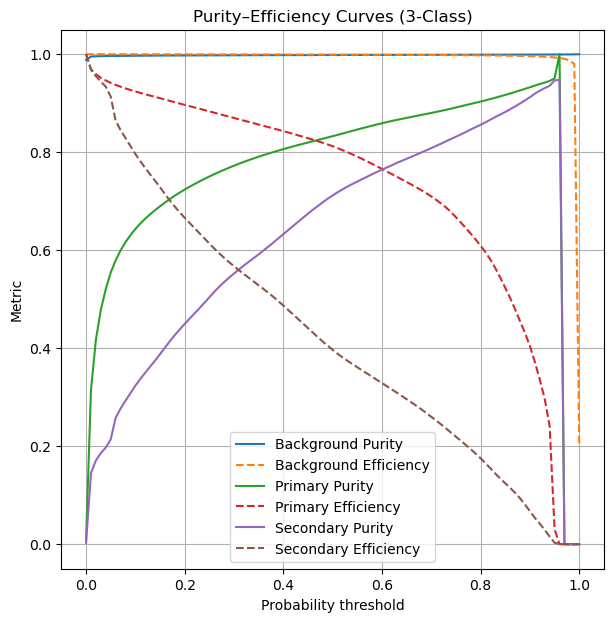

In [2]:
import os
import numpy as np
import torch
import torch.nn as nn
import snntorch as snn
from torch.utils.data import DataLoader, TensorDataset
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
from tqdm import tqdm
from sklearn.metrics import classification_report, confusion_matrix

# ============================================================
# === CONFIG ===
# ============================================================
CACHE_PATH = "cached_data/TimeSeries_seq_3000_batch0.npz"

CHECKPOINT_DIR = "checkpoints_snn_seq_3000_batch0_multiclass_v12"
RESULT_PATH = "results/snn_seq_3000_batch0_multiclass_cluster_v12.npz"
OUT_FIG_BEST = "results/purity_efficiency_best_v12.png"
OUT_FIG_CURVE = "results/training_curve_v12.png"

BATCH_SIZE = 32
NUM_EPOCHS = 10
PATIENCE = 3
NUM_TIMESTEPS = 20
NUM_CLASSES = 3   # ✅ 3-way classification

os.makedirs(CHECKPOINT_DIR, exist_ok=True)
os.makedirs("results", exist_ok=True)

# ============================================================
# === Load dataset ===
# ============================================================
print("Loading dataset...")
data = np.load(CACHE_PATH)
X_train, y_train = data["X_train"], data["y_train"]
X_test, y_test   = data["X_test"], data["y_test"]

print("✅ Shapes before processing:", X_train.shape, y_train.shape, X_test.shape, y_test.shape)

# Clip or map labels
y_train = np.clip(y_train, 0, 2).astype(np.int64)
y_test  = np.clip(y_test, 0, 2).astype(np.int64)

print("Label distribution (train):", np.bincount(y_train.reshape(-1)))
print("Label distribution (test):", np.bincount(y_test.reshape(-1)))

# Normalize input
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train.reshape(-1, 1)).reshape(X_train.shape)
X_test  = scaler.transform(X_test.reshape(-1, 1)).reshape(X_test.shape)

# Torch tensors
X_train_tensor = torch.tensor(X_train, dtype=torch.float32)
y_train_tensor = torch.tensor(y_train, dtype=torch.long)
X_test_tensor  = torch.tensor(X_test, dtype=torch.float32)
y_test_tensor  = torch.tensor(y_test, dtype=torch.long)

train_loader = DataLoader(TensorDataset(X_train_tensor, y_train_tensor),
                          batch_size=BATCH_SIZE, shuffle=True)
test_loader  = DataLoader(TensorDataset(X_test_tensor, y_test_tensor),
                          batch_size=BATCH_SIZE, shuffle=False)

# ============================================================
# === Model ===
# ============================================================
class ConvSNN_Deep(nn.Module):
    def __init__(self, input_dim=1, beta=0.5, num_classes=3):
        super().__init__()
        self.conv1 = nn.Conv1d(input_dim, 32, kernel_size=5, padding=2)
        self.lif1  = snn.Leaky(beta=beta)
        self.conv2 = nn.Conv1d(32, 64, kernel_size=5, padding=2)
        self.lif2  = snn.Leaky(beta=beta)
        self.conv3 = nn.Conv1d(64, 128, kernel_size=5, padding=2)
        self.lif3  = snn.Leaky(beta=beta)
        self.conv4 = nn.Conv1d(128, 128, kernel_size=5, padding=2)
        self.lif4  = snn.Leaky(beta=beta)
        self.fc1   = nn.Linear(128, 128)
        self.lif_fc = snn.Leaky(beta=beta)
        self.fc_out = nn.Linear(128, num_classes)

    def forward(self, x, num_steps=NUM_TIMESTEPS):
        B, T, _ = x.shape
        x = x.permute(0, 2, 1)
        mem1, mem2, mem3, mem4, mem_fc = (
            self.lif1.init_leaky(),
            self.lif2.init_leaky(),
            self.lif3.init_leaky(),
            self.lif4.init_leaky(),
            self.lif_fc.init_leaky(),
        )
        spk_out = []
        for _ in range(num_steps):
            cur1 = self.conv1(x); spk1, mem1 = self.lif1(cur1, mem1)
            cur2 = self.conv2(spk1); spk2, mem2 = self.lif2(cur2, mem2)
            cur3 = self.conv3(spk2); spk3, mem3 = self.lif3(cur3, mem3)
            cur4 = self.conv4(spk3); spk4, mem4 = self.lif4(cur4, mem4)
            spk4 = spk4.permute(0, 2, 1)
            fc = self.fc1(spk4)
            spk_fc, mem_fc = self.lif_fc(fc, mem_fc)
            out = self.fc_out(spk_fc)
            spk_out.append(out)
        return torch.stack(spk_out, dim=2).mean(dim=2)

# ============================================================
# === Load Best Model and Evaluate ===
# ============================================================
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

model = ConvSNN_Deep(num_classes=NUM_CLASSES).to(device)

best_model_path = os.path.join(CHECKPOINT_DIR, "best.pt")
if not os.path.exists(best_model_path):
    raise FileNotFoundError(f"❌ No best.pt found in {CHECKPOINT_DIR}. Train first!")

print(f"🔄 Loading best model from {best_model_path}")
model.load_state_dict(torch.load(best_model_path, map_location=device))
model.eval()

# ============================================================
# === Evaluation ===
# ============================================================
y_true_all, y_pred_all = [], []

with torch.no_grad():
    for xb, yb in tqdm(test_loader, desc="Evaluating"):
        xb = xb.to(device)
        out = model(xb)
        probs = torch.softmax(out, dim=-1).cpu().numpy()
        labels = yb.cpu().numpy()
        y_true_all.append(labels)
        y_pred_all.append(probs)

y_true_all = np.concatenate(y_true_all, axis=0)
y_pred_all = np.concatenate(y_pred_all, axis=0)

np.savez(RESULT_PATH, probs=y_pred_all, y_true=y_true_all)
print(f"✅ Saved results to {RESULT_PATH}")

# ============================================================
# === Purity/Efficiency per class (Fixed) ===
# ============================================================
def purity_efficiency_multiclass(y_true, y_probs, nclasses=3, thresholds=None):
    if thresholds is None:
        thresholds = np.linspace(0, 1, 101)
    results = []
    N, T = y_true.shape
    for cls in range(nclasses):
        yt = (y_true == cls).reshape(-1)
        pp = y_probs[:, :, cls].reshape(-1)
        purity, efficiency = [], []
        for thr in thresholds:
            pred = pp >= thr
            TP = np.sum(pred & yt)
            FP = np.sum(pred & (~yt))
            FN = np.sum((~pred) & yt)
            p = TP / (TP + FP) if (TP + FP) > 0 else 0.0
            e = TP / (TP + FN) if (TP + FN) > 0 else 0.0
            purity.append(p)
            efficiency.append(e)
        results.append((np.array(purity), np.array(efficiency)))
    return thresholds, results

# Run evaluation
tsteps, results = purity_efficiency_multiclass(y_true_all, y_pred_all, nclasses=NUM_CLASSES)

labels = ["Background", "Primary", "Secondary"]
plt.figure(figsize=(7,7))
for i, (pur, eff) in enumerate(results):
    plt.plot(tsteps, pur, label=f"{labels[i]} Purity")
    plt.plot(tsteps, eff, "--", label=f"{labels[i]} Efficiency")
plt.xlabel("Probability threshold")
plt.ylabel("Metric")
plt.title("Purity–Efficiency Curves (3-Class)")
plt.grid(True)
plt.legend()
plt.savefig(OUT_FIG_BEST)
print(f"✅ Saved purity–efficiency curves to {OUT_FIG_BEST}")

# ============================================================
# === Confusion matrix + report ===
# ============================================================
y_pred_label = y_pred_all.argmax(-1).flatten()
y_true_label = y_true_all.flatten()

print("\n=== Classification Report ===")
print(classification_report(y_true_label, y_pred_label, target_names=labels))
print("\n=== Confusion Matrix ===")
print(confusion_matrix(y_true_label, y_pred_label))


Loading dataset...
✅ Shapes before processing: (100000, 3000, 1) (100000, 3000) (100000, 3000, 1) (100000, 3000)
Label distribution (train): [296511283   2639999    848718]
Label distribution (test): [296518112   2640372    841516]


/tmp/ipykernel_373/1533147981.py:113: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load(best_model_path, map_location=device))


Using device: cuda
🔄 Loading best model from checkpoints_snn_seq_3000_batch0_multiclass_v12/best.pt


Evaluating: 100%|██████████| 3125/3125 [04:21<00:00, 11.94it/s]


✅ Saved results to results/snn_seq_3000_batch0_multiclass_cluster_v12.npz
✅ Saved purity–efficiency curves to results/purity_efficiency_best_v12.png

=== Best Thresholds per Class ===

[Background]
Best threshold = 0.460
Purity = 99.83%
Efficiency = 99.93%
Balanced score (F1) = 0.999

[Primary]
Best threshold = 0.420
Purity = 81.19%
Efficiency = 83.74%
Balanced score (F1) = 0.824

[Secondary]
Best threshold = 0.310
Purity = 56.08%
Efficiency = 55.92%
Balanced score (F1) = 0.560

=== Classification Report ===
              precision    recall  f1-score   support

  Background       1.00      1.00      1.00 296518112
     Primary       0.82      0.82      0.82   2640372
   Secondary       0.69      0.42      0.52    841516

    accuracy                           1.00 300000000
   macro avg       0.84      0.75      0.78 300000000
weighted avg       1.00      1.00      1.00 300000000


=== Confusion Matrix ===
[[296328259    134152     55701]
 [   360049   2174269    106054]
 [   155689  

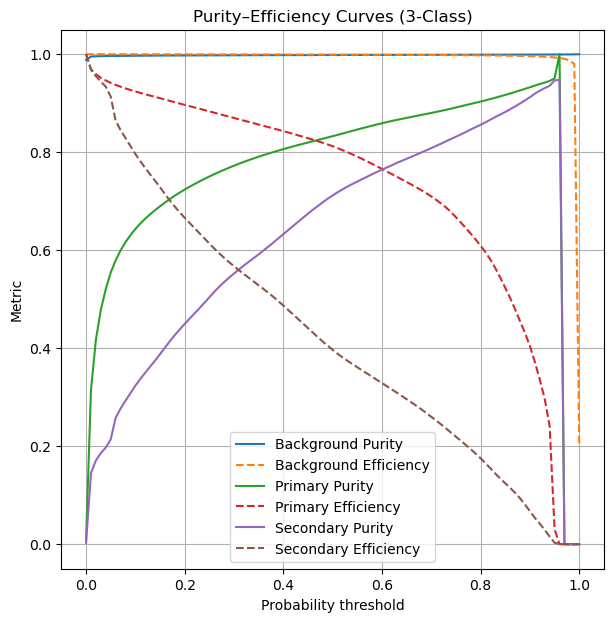

In [3]:
import os
import numpy as np
import torch
import torch.nn as nn
import snntorch as snn
from torch.utils.data import DataLoader, TensorDataset
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
from tqdm import tqdm
from sklearn.metrics import classification_report, confusion_matrix

# ============================================================
# === CONFIG ===
# ============================================================
CACHE_PATH = "cached_data/TimeSeries_seq_3000_batch0.npz"

CHECKPOINT_DIR = "checkpoints_snn_seq_3000_batch0_multiclass_v12"
RESULT_PATH = "results/snn_seq_3000_batch0_multiclass_cluster_v12.npz"
OUT_FIG_BEST = "results/purity_efficiency_best_v12.png"
OUT_FIG_CURVE = "results/training_curve_v12.png"

BATCH_SIZE = 32
NUM_EPOCHS = 10
PATIENCE = 3
NUM_TIMESTEPS = 20
NUM_CLASSES = 3   # ✅ 3-way classification

os.makedirs(CHECKPOINT_DIR, exist_ok=True)
os.makedirs("results", exist_ok=True)

# ============================================================
# === Load dataset ===
# ============================================================
print("Loading dataset...")
data = np.load(CACHE_PATH)
X_train, y_train = data["X_train"], data["y_train"]
X_test, y_test   = data["X_test"], data["y_test"]

print("✅ Shapes before processing:", X_train.shape, y_train.shape, X_test.shape, y_test.shape)

# Clip or map labels
y_train = np.clip(y_train, 0, 2).astype(np.int64)
y_test  = np.clip(y_test, 0, 2).astype(np.int64)

print("Label distribution (train):", np.bincount(y_train.reshape(-1)))
print("Label distribution (test):", np.bincount(y_test.reshape(-1)))

# Normalize input
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train.reshape(-1, 1)).reshape(X_train.shape)
X_test  = scaler.transform(X_test.reshape(-1, 1)).reshape(X_test.shape)

# Torch tensors
X_test_tensor  = torch.tensor(X_test, dtype=torch.float32)
y_test_tensor  = torch.tensor(y_test, dtype=torch.long)
test_loader  = DataLoader(TensorDataset(X_test_tensor, y_test_tensor),
                          batch_size=BATCH_SIZE, shuffle=False)

# ============================================================
# === Model ===
# ============================================================
class ConvSNN_Deep(nn.Module):
    def __init__(self, input_dim=1, beta=0.5, num_classes=3):
        super().__init__()
        self.conv1 = nn.Conv1d(input_dim, 32, kernel_size=5, padding=2)
        self.lif1  = snn.Leaky(beta=beta)
        self.conv2 = nn.Conv1d(32, 64, kernel_size=5, padding=2)
        self.lif2  = snn.Leaky(beta=beta)
        self.conv3 = nn.Conv1d(64, 128, kernel_size=5, padding=2)
        self.lif3  = snn.Leaky(beta=beta)
        self.conv4 = nn.Conv1d(128, 128, kernel_size=5, padding=2)
        self.lif4  = snn.Leaky(beta=beta)
        self.fc1   = nn.Linear(128, 128)
        self.lif_fc = snn.Leaky(beta=beta)
        self.fc_out = nn.Linear(128, num_classes)

    def forward(self, x, num_steps=NUM_TIMESTEPS):
        B, T, _ = x.shape
        x = x.permute(0, 2, 1)
        mem1, mem2, mem3, mem4, mem_fc = (
            self.lif1.init_leaky(),
            self.lif2.init_leaky(),
            self.lif3.init_leaky(),
            self.lif4.init_leaky(),
            self.lif_fc.init_leaky(),
        )
        spk_out = []
        for _ in range(num_steps):
            cur1 = self.conv1(x); spk1, mem1 = self.lif1(cur1, mem1)
            cur2 = self.conv2(spk1); spk2, mem2 = self.lif2(cur2, mem2)
            cur3 = self.conv3(spk2); spk3, mem3 = self.lif3(cur3, mem3)
            cur4 = self.conv4(spk3); spk4, mem4 = self.lif4(cur4, mem4)
            spk4 = spk4.permute(0, 2, 1)
            fc = self.fc1(spk4)
            spk_fc, mem_fc = self.lif_fc(fc, mem_fc)
            out = self.fc_out(spk_fc)
            spk_out.append(out)
        return torch.stack(spk_out, dim=2).mean(dim=2)

# ============================================================
# === Load Best Model ===
# ============================================================
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

model = ConvSNN_Deep(num_classes=NUM_CLASSES).to(device)
best_model_path = os.path.join(CHECKPOINT_DIR, "best.pt")

if not os.path.exists(best_model_path):
    raise FileNotFoundError(f"❌ No best.pt found in {CHECKPOINT_DIR}. Train first!")

print(f"🔄 Loading best model from {best_model_path}")
model.load_state_dict(torch.load(best_model_path, map_location=device))
model.eval()

# ============================================================
# === Evaluation ===
# ============================================================
y_true_all, y_pred_all = [], []

with torch.no_grad():
    for xb, yb in tqdm(test_loader, desc="Evaluating"):
        xb = xb.to(device)
        out = model(xb)
        probs = torch.softmax(out, dim=-1).cpu().numpy()
        labels = yb.cpu().numpy()
        y_true_all.append(labels)
        y_pred_all.append(probs)

y_true_all = np.concatenate(y_true_all, axis=0)
y_pred_all = np.concatenate(y_pred_all, axis=0)

np.savez(RESULT_PATH, probs=y_pred_all, y_true=y_true_all)
print(f"✅ Saved results to {RESULT_PATH}")

# ============================================================
# === Purity/Efficiency per class + Best threshold ===
# ============================================================
def purity_efficiency_multiclass(y_true, y_probs, nclasses=3, thresholds=None):
    if thresholds is None:
        thresholds = np.linspace(0, 1, 101)
    results = []
    N, T = y_true.shape
    for cls in range(nclasses):
        yt = (y_true == cls).reshape(-1)
        pp = y_probs[:, :, cls].reshape(-1)
        purity, efficiency = [], []
        for thr in thresholds:
            pred = pp >= thr
            TP = np.sum(pred & yt)
            FP = np.sum(pred & (~yt))
            FN = np.sum((~pred) & yt)
            p = TP / (TP + FP) if (TP + FP) > 0 else 0.0
            e = TP / (TP + FN) if (TP + FN) > 0 else 0.0
            purity.append(p)
            efficiency.append(e)
        purity, efficiency = np.array(purity), np.array(efficiency)
        f1 = 2 * (purity * efficiency) / (purity + efficiency + 1e-9)
        best_idx = np.nanargmax(f1)
        results.append({
            "class": cls,
            "threshold": thresholds[best_idx],
            "purity": purity[best_idx],
            "efficiency": efficiency[best_idx],
            "f1": f1[best_idx],
            "purity_curve": purity,
            "eff_curve": efficiency,
            "thresholds": thresholds
        })
    return results

results = purity_efficiency_multiclass(y_true_all, y_pred_all, nclasses=NUM_CLASSES)

labels = ["Background", "Primary", "Secondary"]
plt.figure(figsize=(7,7))
for i, res in enumerate(results):
    plt.plot(res["thresholds"], res["purity_curve"], label=f"{labels[i]} Purity")
    plt.plot(res["thresholds"], res["eff_curve"], "--", label=f"{labels[i]} Efficiency")
plt.xlabel("Probability threshold")
plt.ylabel("Metric")
plt.title("Purity–Efficiency Curves (3-Class)")
plt.grid(True)
plt.legend()
plt.savefig(OUT_FIG_BEST)
print(f"✅ Saved purity–efficiency curves to {OUT_FIG_BEST}")

# Print best thresholds
print("\n=== Best Thresholds per Class ===")
for i, res in enumerate(results):
    print(f"\n[{labels[i]}]")
    print(f"Best threshold = {res['threshold']:.3f}")
    print(f"Purity = {res['purity']*100:.2f}%")
    print(f"Efficiency = {res['efficiency']*100:.2f}%")
    print(f"Balanced score (F1) = {res['f1']:.3f}")

# ============================================================
# === Confusion matrix + summary ===
# ============================================================
y_pred_label = y_pred_all.argmax(-1).flatten()
y_true_label = y_true_all.flatten()

print("\n=== Classification Report ===")
print(classification_report(y_true_label, y_pred_label, target_names=labels))
print("\n=== Confusion Matrix ===")
print(confusion_matrix(y_true_label, y_pred_label))
